<h1>Sentiment Analysis with LSTM</h1>

<h2>1. Project Overview</h2>

<p>
This project applies deep learning techniques to a <strong>sentiment analysis</strong> task using the Stanford Sentiment Treebank (SST) dataset. 
The goal is to classify sentences into sentiment categories (positive, negative, and neutral).
</p>

<p>
The dataset consists of labeled sentences and phrases, where each example represents a piece of text with an associated sentiment. 
After preprocessing, the text is tokenized, numericalized, and converted into sequences suitable for neural network input.
</p>

<p>
This architecture improves upon a basic RNN by combining pretrained embeddings, convolutional layers, a bidirectional LSTM, and attention to better capture both local patterns and long-range dependencies in text.
</p>

In [ ]:
# Install torch package
!pip install torch torchvision torchtext --index-url https://download.pytorch.org/whl/cu118

In [ ]:
# Import torch
import torch
print(torch.__version__)

2.6.0+cu118


In [ ]:
# Import libraries
import copy
from torch import nn
from torch import optim
import torchtext
from torchtext import data
from torchtext import datasets
from collections import Counter
import matplotlib.pyplot as plt
from torchtext.vocab import GloVe
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Data preprocessing
TEXT = data.Field(sequential=True, batch_first=True, lower=True) # Input text will be tokenized as a sequence, shape with batch dim first, lowercased
LABEL = data.LabelField() # Labels will be processed as numerical encoding

# Load data splits
train_data, val_data, test_data = datasets.SST.splits(TEXT, LABEL)

# Build dictionary
TEXT.build_vocab(train_data) # Assigns unique index to every token
LABEL.build_vocab(train_data) # Assigns numerical encoding to target labels

# Define device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Configuration and hyperparameters
vocab_size = len(TEXT.vocab) # Number of unique tokens
label_size = len(LABEL.vocab) # Number of unique target labels
hidden_dim = 128 # Size of hidden state vector

glove = GloVe(name='6B', dim=300) # Load GloVe pretrained word embeddings
embedding_dim = glove.dim # Store the dimensionality of each embedding vector
embedding_weights = glove.vectors.to(device)  # Ensure glove vectors are on the same device

unk_idx = TEXT.vocab.stoi['<unk>'] # Index of the special <unk> or unknown token
pad_idx = TEXT.vocab.stoi['<pad>'] # Index of the <pad> token, used to pad sequences to equal length within a batch
neutral_idx = LABEL.vocab.stoi['neutral'] # Integer index assigned to the neutral label
lambda_coeff = 0.05 # Hyperparameter encouraging model to assign higher probability to the neutral class when encountering <unk> tokens

# Build data iterators for training, validation and testing
train_iter, val_iter, test_iter = data.BucketIterator.splits(
    (train_data, val_data, test_data),
    batch_size=64, device=device
    )

In [ ]:
# Build embedding matrix using pretrained GloVe vectors
embedding_matrix = torch.zeros(len(TEXT.vocab), glove.dim) # Initializes a zero matrix to hold embeddings
for i, token in enumerate(TEXT.vocab.itos): # For each token in vocabulary
    if token in glove.stoi:
        embedding_matrix[i] = glove.vectors[glove.stoi[token]] # If found in GloVe, copy the pretrained vector
    else:
        embedding_matrix[i] = torch.randn(glove.dim) # If not, assign a random vector

# Zero out <unk> and <pad> tokens to suppress their influence in attention
embedding_matrix[unk_idx] = torch.zeros(glove.dim)
embedding_matrix[pad_idx] = torch.zeros(glove.dim)

# Move embedding matrix to device
embedding_matrix = embedding_matrix.to(device)

In [ ]:
# Define model
class LSTMAttnClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, label_size, pad_idx, unk_idx, dropout=0.1):
        super(LSTMAttnClassifier, self).__init__()

        # Initialize embedding layer using pretrained vectors
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=pad_idx)

        # Add three convolutional layers, one for each kernel size to extract bigrams, trigrams, and 4-grams features
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=k)
            for k in [2, 3, 4]])

        # Dropout after convolutional layer
        self.dropout = nn.Dropout(dropout)

        # LSTM processes CNN-enhanced features, captures temporal dependencies
        self.lstm = nn.LSTM(input_size=100 * len(self.convs), # Total output size from all CNN filters
                            hidden_size=hidden_dim,
                            batch_first=True,
                            bidirectional=True, # Process the input sequence in both forward and backward directions
                            num_layers=2, # Two stacked LSTM layers
                            dropout=0.1) # Dropout between stacked LSTM layers

        # LayerNorm for stabilizing LSTM outputs
        self.norm = nn.LayerNorm(hidden_dim * 2)

        # Attention mechanism over LSTM outputs
        self.attn = nn.Linear(hidden_dim * 2, 1) # Linear layer to score LSTM outputs for attention computation
        self.dropout = nn.Dropout(dropout) # Dropout after attention and before final classification

        # Final linear classifier to map context vector to label logits
        self.fc = nn.Linear(hidden_dim * 2, label_size)

        # Store pad and unk token indices for masking
        self.pad_idx = pad_idx
        self.unk_idx = unk_idx

    def forward(self, text, mask=None): # text: [batch_size, seq_len]

      # Embed input tokens and rearrange for Convolusion layer one: [batch, emb_dim, seq_len]
      embedded = self.embedding(text) # [batch, seq_len, emb_dim]
      embedded = embedded.permute(0, 2, 1) # [batch, emb_dim, seq_len]

      # Apply Conv -> ReLU -> Dropout for each kernel size
      conv_outs = [self.dropout(F.relu(conv(embedded))) for conv in self.convs]
      # Trim conv outputs to the shortest one to allow stacking, tensors to have shape [batch, filters, min_len]
      min_len = min([out.size(2) for out in conv_outs])
      conv_outs = [out[:, :, :min_len] for out in conv_outs]
      # Concatenate convolutional outputs and reshape to [batch, min_len, total_filters] for LSTM input
      cnn_feat = torch.cat(conv_outs, dim=1).permute(0, 2, 1)

      # Pass through LSTM (bidirectional, stacked)
      lstm_out, _ = self.lstm(cnn_feat)
      lstm_out = self.norm(lstm_out) # Normalize hidden states

      # Compute attention scores from LSTM output
      energy = torch.tanh(lstm_out)
      attn_scores = self.attn(energy).squeeze(-1) # [batch, seq_len]

      # Create combined mask to ignore padding and unknown tokens during attention
      if mask is None:
          mask = (text != self.pad_idx)
      unk_mask = (text != self.unk_idx)
      combined_mask = mask & unk_mask

    # Align mask and attention score dimensions if there's mismatch (added as model showed mismatch)
      if combined_mask.size(1) > attn_scores.size(1):
          combined_mask = combined_mask[:, :attn_scores.size(1)]
      elif combined_mask.size(1) < attn_scores.size(1):
          attn_scores = attn_scores[:, :combined_mask.size(1)]

      # Apply mask to attention scores; ensures the attention mechanism ignores padded or unwanted tokens
      mask_fill = attn_scores.masked_fill(~combined_mask, float('-inf'))

      # Handle fully masked rows (added to correct NaNs)
      all_masked = ~combined_mask.any(dim=1)  # [batch] boolean
      mask_fill[all_masked] = 0  # Assign neutral logits for those rows

      # Normalize scores into attention weights
      attn_weights = F.softmax(mask_fill, dim=1)

      # Compute weighted sum of LSTM outputs using attention weights
      context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)

      # Final dropout and classification
      output = self.dropout(context)
      return self.fc(output), attn_weights # Logits and attention map

In [ ]:
# Define criterion, optimizer and scheduler

# Assign higher weight to less frequent classes
class_counts = torch.tensor([444, 428, 229], dtype=torch.float)
class_weights = 1.0 / class_counts # Invert the count of samples per class
class_weights = class_weights / class_weights.sum()  # Normalize to sum to 1

# Use weighted cross-entropy as loss function
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Adam optimizer with learning rate of 2e-4 and weight decay for L2 regularization
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay= 1e-4)

# Learning rate scheduler decays the learning rate by a factor of 0.5 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [ ]:
# Instantiate model
model = LSTMAttnClassifier(
    vocab_size=len(TEXT.vocab),
    embedding_dim=glove.dim,
    hidden_dim=hidden_dim,
    label_size=label_size,
    pad_idx=pad_idx,
    unk_idx=unk_idx)

model = model.to(device)

In [ ]:
# Training function, runs one full pass over the training data
def train(model, data_iterator, optimizer, criterion, device):
    model.train() # Set model to training mode
    epoch_loss = 0 # Initialize loss accumulated over the epoch
    epoch_acc = 0 # Initialize accuracy accumulated over the epoch

    for batch in data_iterator: # Iterate over batches
        inputs = batch.text.to(device) # Input sequences, move to device
        labels = batch.label.to(device) # Corresponding labels, move to device

        mask = (inputs != pad_idx)  # Create mask for non-padding tokens for attention
        predictions = model(inputs, mask=mask)  # Forward pass with mask to get predictions

        logits, _ = model(inputs, mask=mask) # Get logits or raw scores
        loss = criterion(logits, labels) # Compute loss between predictions and true labels

        # Add soft neutral-bias regularization for <unk>
        if (inputs == unk_idx).any():
          neutrality_prob = F.softmax(predictions, dim=1)[:, neutral_idx] # Probability assigned to neutral class
          loss -= lambda_coeff * neutrality_prob.mean()  # Move model toward neutrality on inputs containing <unk>

        acc = (logits.argmax(dim=1) == labels).sum().item() / len(labels) # Compute batch accuracy

        optimizer.zero_grad() # Reset old gradients
        loss.backward() # Backward pass, compute gradients
        optimizer.step() # Update model parameters using optimizer

        epoch_loss += loss.item() # Add batch loss to total
        epoch_acc += acc # Add batch accuracy to total

    # Return average loss and accuracy over entire epoch
    return epoch_loss / len(data_iterator), epoch_acc / len(data_iterator)

# Evaluation function
def evaluate(model, data_iterator, criterion, device):
    model.eval() # Set model to evaluation mode
    epoch_loss = 0 # Initialize loss accumulated over the epoch
    epoch_acc = 0 # Initialize accuracy accumulated over the epoch

    with torch.no_grad(): # Disable gradient tracking
        for batch in data_iterator: # Iterate over batches
            inputs = batch.text.to(device) # Input sequences, move to device
            labels = batch.label.to(device) # Corresponding labels, move to device

            # Mask excludes padding and unknown tokens for cleaner attention
            mask = (inputs != pad_idx) & (inputs != unk_idx)

            logits, _ = model(inputs, mask=mask)  # Forward pass with attention mask
            loss = criterion(logits, labels) # Compute loss
            preds = logits.argmax(dim=1)  # Get predicted class labels
            acc = (preds == labels).sum().item() / len(labels)  # Compute accuracy for the batch

            epoch_loss += loss.item() # Add batch loss to total
            epoch_acc += acc # Add batch accuracy to total

    # Return average loss and accuracy over entire epoch
    return epoch_loss / len(data_iterator), epoch_acc / len(data_iterator)

In [ ]:
# Training loop and evaluation

num_epochs = 20 # Number of epochs

# Initialize variables for early stopping
best_val_acc = 0 # Best validation accuracy
best_val_loss = float('inf') # Lowest validation loss
patience = 10 # Number of epochs with no improving before stopping
counter = 0 # Counts epochs without improvement
best_model_state = None # Stores parameters of the best model
best_epoch = 0 # Epoch with best performance

# Initialize variables for loss and accuracy plots
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Train model for a number of epochs
for epoch in range(num_epochs):
    # Train on training set and evaluate on validation set
    train_loss, train_acc = train(model, train_iter, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_iter, criterion, device)

    # Append metrics for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Early stopping at best validation performance
    if val_acc > best_val_acc:
      best_val_acc = val_acc # Update best accuracy
      best_val_loss = val_loss # Update best loss
      best_epoch = epoch + 1 # Record epoch number
      best_model_state = copy.deepcopy(model.state_dict())  # Save model weights
      counter = 0 # Reset patience counter
    else:
      counter += 1 # Increment counter if no improvement
      print(f"No improvement. Patience counter: {counter}/{patience}")
      if counter >= patience: # Trigger early stopping if patience was reached
        print("Early stopping triggered.")
        break

    # Print results per epoch
    print(f"Epoch {epoch+1}:")
    print(f" Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.2%}")
    print(f" Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.2%}")

    # Step the learning rate scheduler
    scheduler.step()

# Print best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f" Loaded best model from epoch {best_epoch} with:")
    print(f" Validation Accuracy: {best_val_acc:.2%}")
    print(f" Validation Loss: {best_val_loss:.4f}")

Epoch 1:
 Train Loss: 0.9961 | Accuracy: 52.62%
 Val Loss: 0.9466 | Accuracy: 62.43%
Epoch 2:
 Train Loss: 0.8579 | Accuracy: 63.20%
 Val Loss: 0.9110 | Accuracy: 64.18%
No improvement. Patience counter: 1/10
Epoch 3:
 Train Loss: 0.7519 | Accuracy: 69.37%
 Val Loss: 0.8994 | Accuracy: 63.57%
Epoch 4:
 Train Loss: 0.6627 | Accuracy: 73.40%
 Val Loss: 0.9737 | Accuracy: 65.38%
No improvement. Patience counter: 1/10
Epoch 5:
 Train Loss: 0.5295 | Accuracy: 79.64%
 Val Loss: 1.2319 | Accuracy: 60.10%
No improvement. Patience counter: 2/10
Epoch 6:
 Train Loss: 0.3269 | Accuracy: 89.17%
 Val Loss: 1.3866 | Accuracy: 63.41%
No improvement. Patience counter: 3/10
Epoch 7:
 Train Loss: 0.2280 | Accuracy: 92.58%
 Val Loss: 1.5112 | Accuracy: 62.28%
No improvement. Patience counter: 4/10
Epoch 8:
 Train Loss: 0.1563 | Accuracy: 95.10%
 Val Loss: 1.6556 | Accuracy: 61.57%
No improvement. Patience counter: 5/10
Epoch 9:
 Train Loss: 0.1106 | Accuracy: 96.47%
 Val Loss: 1.8239 | Accuracy: 63.91%
N

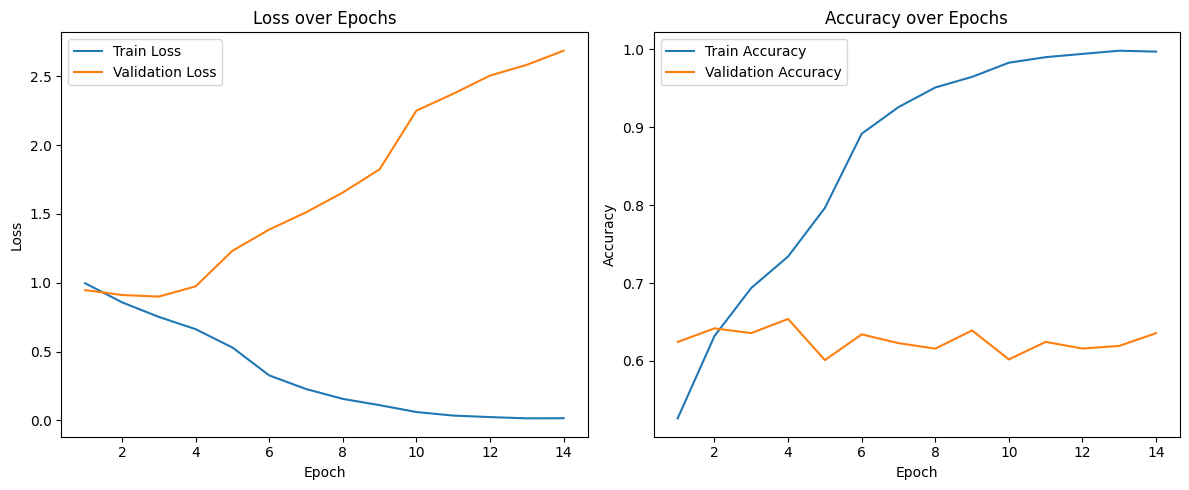

In [ ]:
# Define epochs for plots
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix
# Collect predictions and true labels
all_preds = []
all_labels = []
all_inputs = []

model.eval()
with torch.no_grad():
    for batch in val_iter:
        inputs = batch.text.to(device)
        labels = batch.label.to(device)
        mask = (inputs != pad_idx)

        outputs = model(inputs, mask=mask)
        logits, _ = model(inputs, mask=mask)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_inputs.extend(inputs.cpu().tolist())

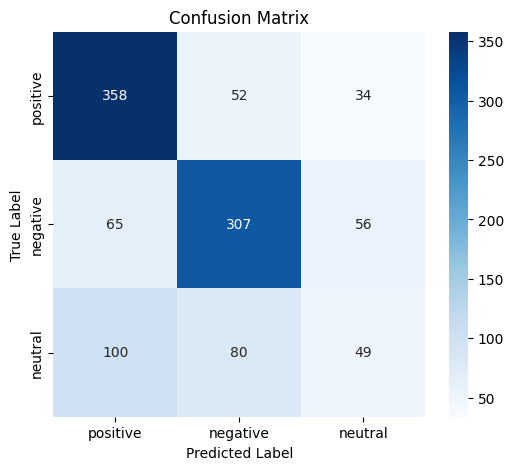

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Define class labels
class_names = ['positive', 'negative', 'neutral']

# Create plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

<h2>2. Model Architecture</h2>

<p style="text-align: center;">
  Input Sequence (tokenized text)  
  <br>↓<br>
  GloVe Embedding Layer (300-dimensional vectors)  
  <br>↓<br>
  Convolutional Layers (kernel sizes 2, 3, 4)  
  <br>↓<br>
  ReLU → Dropout → Concatenation  
  <br>↓<br>
  Bidirectional LSTM (2 layers)  
  <br>↓<br>
  Layer Normalization  
  <br>↓<br>
  Attention Mechanism (context vector)  
  <br>↓<br>
  Dropout  
  <br>↓<br>
  Fully Connected Layer  
  <br>↓<br>
  Output (sentiment logits)
</p><br>


<h2>3. Architectural Enhancements</h2>

<h3>GloVe Pretrained Embeddings</h3>
<p>
Pretrained word embeddings from <strong>GloVe</strong> (300 dimensions, trained on 6 billion tokens) were used to initialize word representations.
</p>

<p>
These embeddings provide rich semantic information, allowing the model to capture relationships between words (e.g., "good" vs "bad") without learning them from scratch. This is particularly beneficial for smaller datasets, improving generalization and convergence.
</p>

<h3>Convolutional Layers</h3>

<p>
Three convolutional layers with kernel sizes 2, 3, and 4 were used to capture local patterns in text, such as bigrams and trigrams.
</p>

<p>
These layers help identify meaningful word combinations, including negations and common phrases (e.g., "not good", "very interesting"), enhancing the model’s ability to extract semantic features before sequence modeling.
</p>

<h3>Bidirectional LSTM</h3>

<p>
A two-layer bidirectional LSTM processes the sequence in both forward and backward directions, capturing contextual dependencies from both past and future tokens.
</p>

<p>
This improves the model’s ability to interpret ambiguous or context-dependent sentences, such as "It's kind of OK".
</p>

<h3>Layer Normalization</h3>

<p>
Layer normalization is applied to stabilize LSTM outputs by normalizing hidden states. 
This results in smoother training dynamics and more stable gradients.
</p>

<p>
In the validation accuracy curve, this can be observed as reduced fluctuations compared to models without normalization.
</p>

<h3>Attention Mechanism</h3>

<p>
Recurrent models process tokens sequentially and may place greater emphasis on nearby or recent context, whereas attention assigns importance weights across the sequence, allowing the model to highlight the most relevant tokens regardless of position.
</p>
<p>
An attention mechanism is applied over the LSTM outputs to identify and emphasize the most informative tokens in a sentence.
</p>

<ul>
  <li>Compute attention scores from LSTM hidden states using a tanh activation followed by a linear layer</li>
  <li>Mask padding and unknown tokens</li>
  <li>Normalize scores using softmax to obtain attention weights</li>
  <li>Compute a weighted sum of hidden states to form a context vector</li>
</ul>

<p>
Recurrent models process tokens sequentially and may place greater emphasis on nearby or recent context, whereas attention assigns importance weights across the sequence, allowing the model to highlight the most relevant tokens regardless of position.
</p>
<p>
While LSTMs process sequences sequentially and tend to emphasize recent tokens, attention considers all tokens simultaneously and assigns importance dynamically.
</p>

<p>
This is particularly useful for sentences where sentiment depends on context or subtle cues. For example, the sentence "Not nearly long enough" was labeled as neutral but predicted as negative. Cases like this illustrate how subtle context and phrasing can shift interpretation, making neutral sentiment especially difficult to classify.
</p>

<h3>Additional Improvements</h3>

<p>
To address class imbalance, weighted cross-entropy loss was used. 
Additionally, a soft neutral-bias regularization term was introduced to encourage neutral predictions when unknown tokens (&lt;unk&gt;) are present.
</p>

<h2>4. Results</h2>

<p>
The final model achieved a validation accuracy of <strong>65.38%</strong>. 
Training and validation curves indicate improved stability compared to earlier recurrent models, reflecting the benefits of pretrained embeddings, normalization, regularization, and architectural enhancements.
</p>

<h3>Confusion Matrix Insights</h3>

<p>
The confusion matrix shows that <strong>neutral sentences were the most frequently misclassified</strong>. 
This is expected, as neutral sentiment often overlaps with positive or negative language and depends heavily on broader sentence context.
</p>

<ul>
  <li>Neutral examples were often confused with negative sentiment</li>
  <li>Subtle phrasing and ambiguous expressions reduced classification accuracy</li>
  <li>These results highlight the difficulty of modeling nuanced sentiment using recurrent architectures</li>
</ul>

In [ ]:
# Look at examples of attention intensity per token
def visualize_attention(model, sentence, TEXT, pad_idx, device):
    model.eval()

    # Tokenize and numericalize the sentence
    tokens = [token.lower() for token in sentence.split()]
    indices = [TEXT.vocab.stoi[token] for token in tokens]
    tensor = torch.LongTensor(indices).unsqueeze(0).to(device)  # [1, seq_len]

    # Create attention mask
    mask = (tensor != pad_idx)

    # Forward pass and get attention weights
    with torch.no_grad():
        embedded = model.embedding(tensor)
        lstm_out, _ = model.lstm(embedded)
        energy = torch.tanh(lstm_out)  # ← optional if used in training
        scores = model.attn(energy).squeeze(-1)

        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))

        attn_weights = torch.softmax(scores, dim=1).squeeze(0).cpu().numpy()

    # Plot attention over tokens
    plt.figure(figsize=(12, 1.5))
    sns.heatmap([attn_weights], annot=[tokens], fmt='', cmap='Blues', cbar=False,
                xticklabels=tokens, yticklabels=[])
    plt.title('Attention Intensity per Token')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
misclassified = []
for pred, label, input_ids in zip(all_preds, all_labels, all_inputs):
    if pred != label:
        misclassified.append((input_ids, pred, label))

True Label: neutral, Predicted: positive


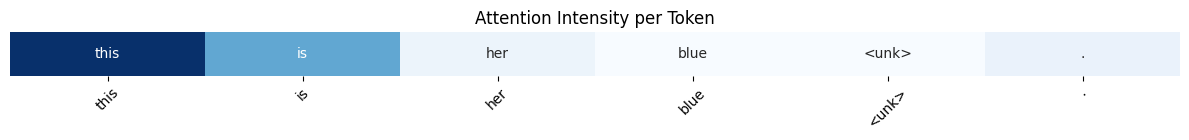

True Label: negative, Predicted: positive


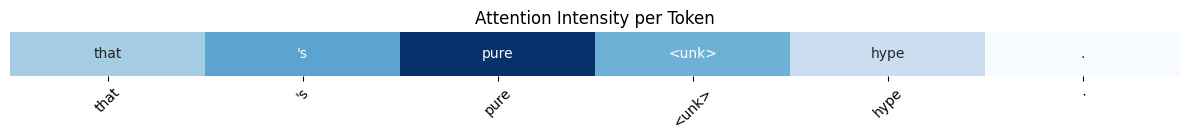

True Label: neutral, Predicted: positive


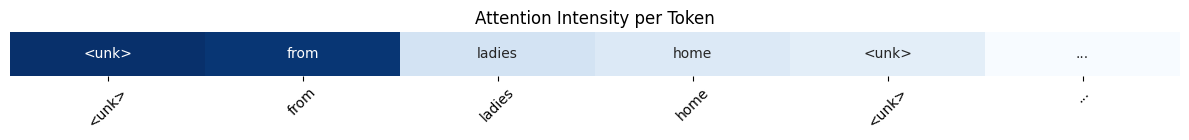

True Label: negative, Predicted: neutral


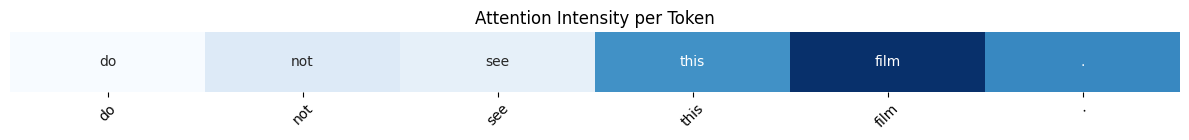

True Label: neutral, Predicted: negative


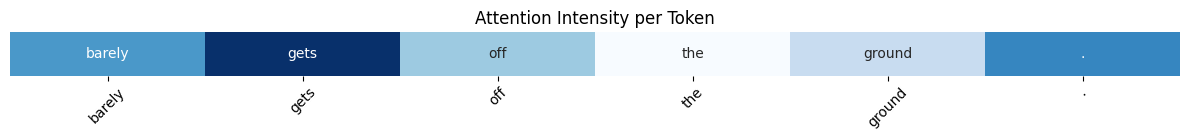

True Label: negative, Predicted: neutral


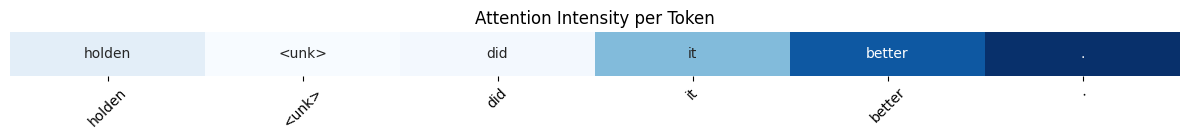

True Label: negative, Predicted: neutral


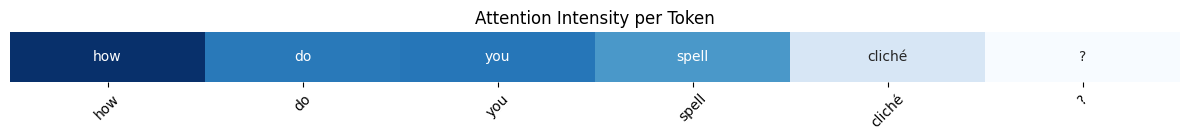

True Label: negative, Predicted: neutral


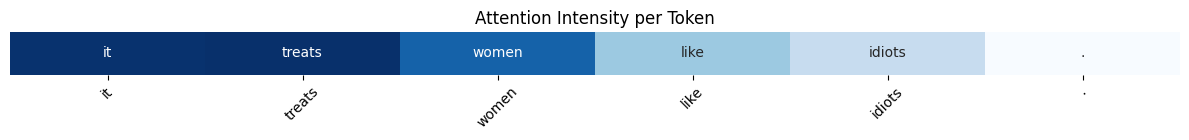

True Label: neutral, Predicted: positive


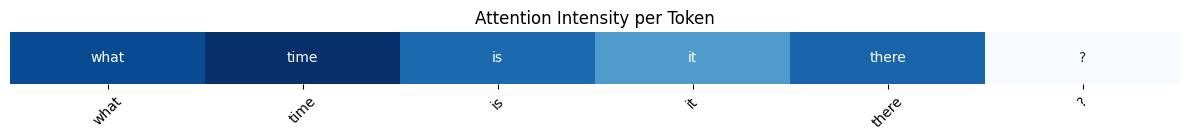

True Label: neutral, Predicted: positive


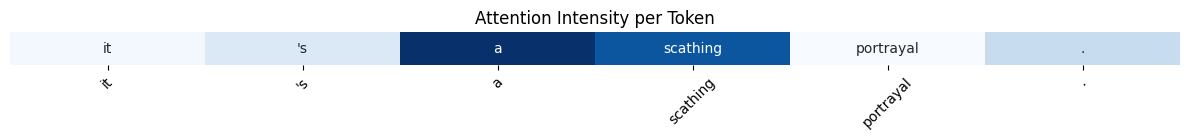

True Label: neutral, Predicted: positive


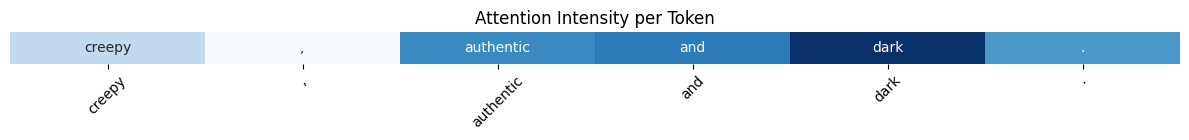

True Label: neutral, Predicted: negative


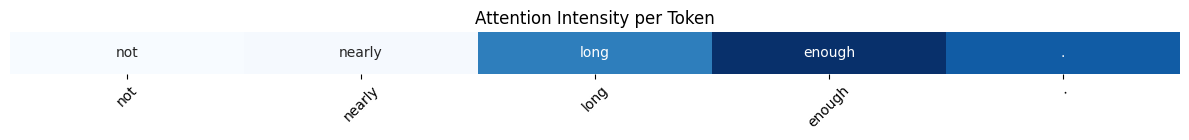

True Label: negative, Predicted: neutral


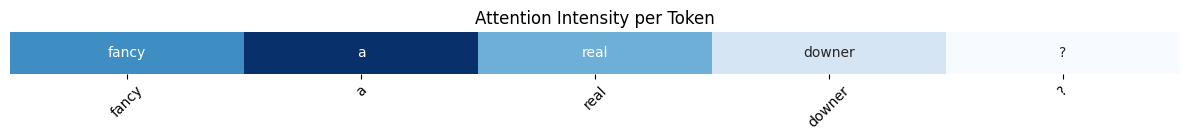

True Label: neutral, Predicted: negative


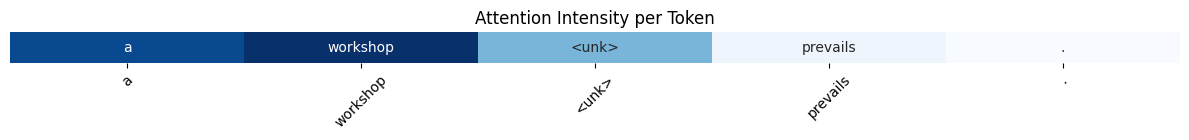

True Label: neutral, Predicted: negative


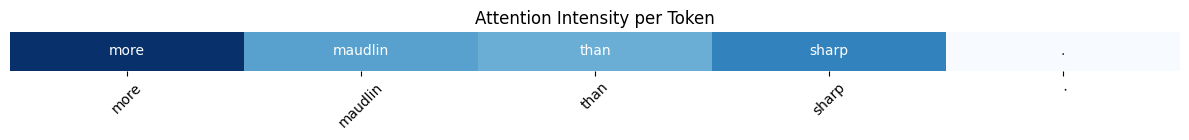

True Label: positive, Predicted: negative


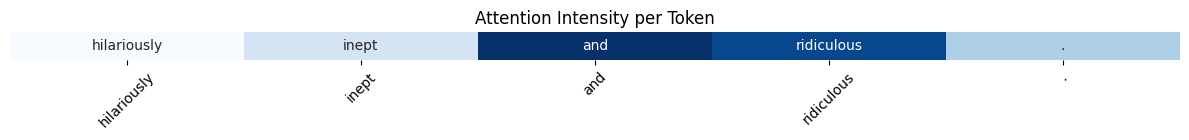

True Label: negative, Predicted: neutral


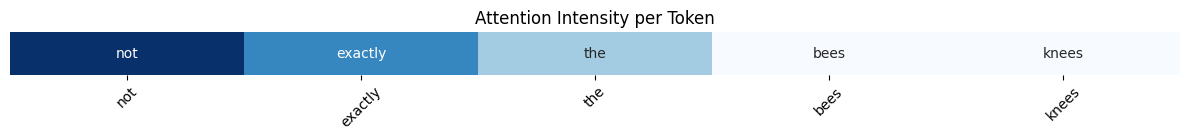

True Label: neutral, Predicted: negative


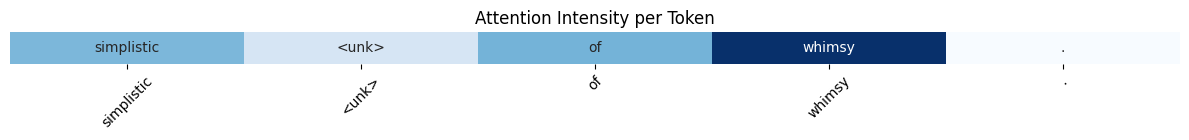

True Label: positive, Predicted: neutral


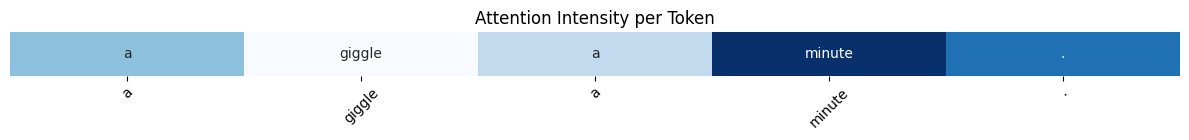

True Label: positive, Predicted: negative


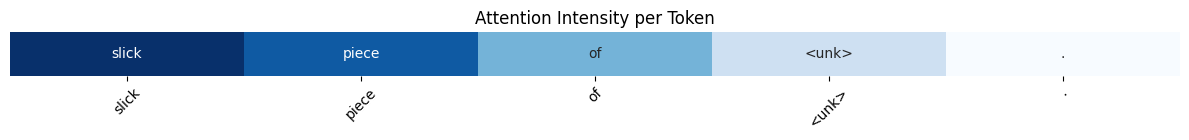

True Label: positive, Predicted: neutral


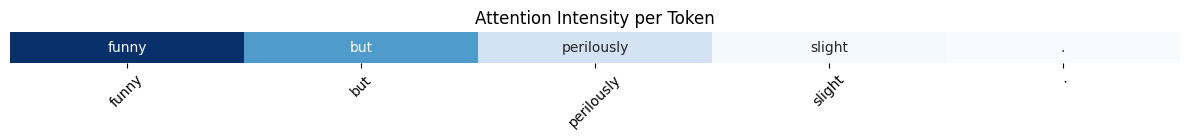

True Label: neutral, Predicted: positive


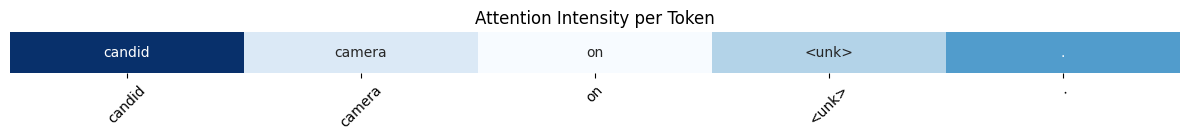

True Label: neutral, Predicted: negative


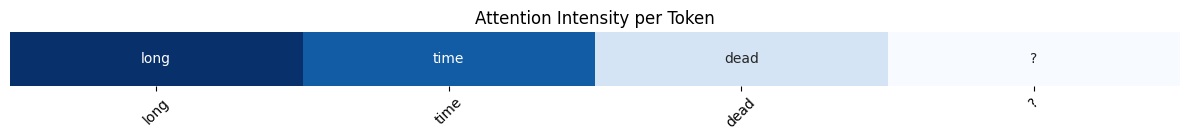

True Label: negative, Predicted: neutral


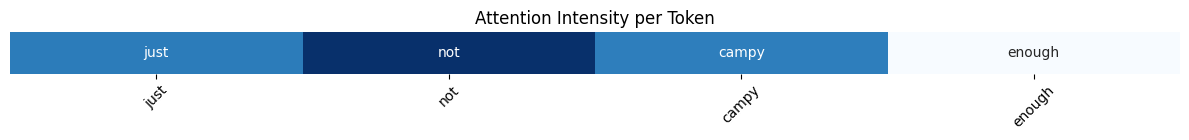

True Label: negative, Predicted: positive


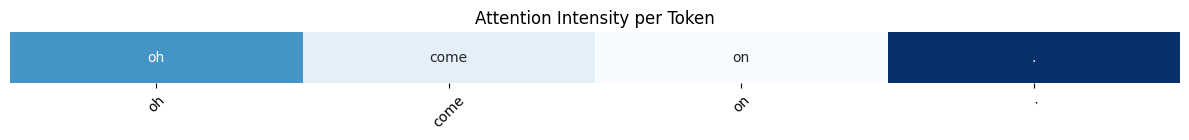

In [ ]:
for input_ids, pred, label in misclassified[:25]:
    tokens = [TEXT.vocab.itos[i] for i in input_ids if i != pad_idx]

    print(f"True Label: {LABEL.vocab.itos[label]}, Predicted: {LABEL.vocab.itos[pred]}")
    visualize_attention(model, ' '.join(tokens), TEXT, pad_idx, device)

In [ ]:
# Identify top attended tokens in misclassified samples
from collections import defaultdict

# Dictionary of dicts: {class_label → {token_id → [weights]}}
classwise_attn = defaultdict(lambda: defaultdict(list))

model.eval()
with torch.no_grad():
    for batch in val_iter:
        inputs = batch.text.to(device)
        labels = batch.label.to(device)
        mask = (inputs != pad_idx) & (inputs != unk_idx)
        logits, attn_weights = model(inputs, mask=mask)
        preds = logits.argmax(dim=1)

        misclassified = preds != labels
        for i in range(inputs.size(0)):
            if misclassified[i]:
                pred_class = preds[i].item()
                seq_len = min(inputs.size(1), attn_weights.size(1))
                for j in range(seq_len):
                    if mask[i, j]:
                        token_id = inputs[i, j].item()
                        weight = attn_weights[i, j].item()
                        classwise_attn[pred_class][token_id].append(weight)


In [ ]:
for cls in classwise_attn:
    print(f"\n Top attended tokens for class '{LABEL.vocab.itos[cls]}' (misclassified samples):")
    token_weights = {
        tid: sum(weights)/len(weights)
        for tid, weights in classwise_attn[cls].items()
        if TEXT.vocab.itos[tid] not in ["<pad>", "<unk>", ","]
    }
    top_tokens = sorted(token_weights.items(), key=lambda x: x[1], reverse=True)[:10]
    for tid, avg_w in top_tokens:
        print(f"{TEXT.vocab.itos[tid]:<12} — Avg Attention: {avg_w:.4f}")



 Top attended tokens for class 'positive' (misclassified samples):
ladies       — Avg Attention: 0.5575
oh           — Avg Attention: 0.5253
chilling     — Avg Attention: 0.5076
candid       — Avg Attention: 0.4770
creepy       — Avg Attention: 0.4669
pretension   — Avg Attention: 0.3534
84           — Avg Attention: 0.3394
sadistic     — Avg Attention: 0.3286
forgettable  — Avg Attention: 0.3263
camera       — Avg Attention: 0.3026

 Top attended tokens for class 'neutral' (misclassified samples):
holden       — Avg Attention: 0.7710
implausible  — Avg Attention: 0.7395
cool         — Avg Attention: 0.6889
chokes       — Avg Attention: 0.6390
k-19         — Avg Attention: 0.4827
jaglom       — Avg Attention: 0.4719
fancy        — Avg Attention: 0.3884
nervous      — Avg Attention: 0.3507
sputters     — Avg Attention: 0.3498
how          — Avg Attention: 0.3444

 Top attended tokens for class 'negative' (misclassified samples):
simplistic   — Avg Attention: 0.7297
slick        — Avg A

<h2>5. Error Analysis</h2>

<p>
To better understand model performance, misclassified examples were analyzed using both confusion matrix results and attention visualizations.
</p>

<h3>Class-Level Patterns</h3>

<p>
The confusion matrix shows that <strong>neutral sentences were the most frequently misclassified</strong>. 
This reflects the inherent difficulty of neutral sentiment, which often overlaps with both positive and negative language.
</p>

<ul>
  <li>Neutral sentences frequently contain mixed or subtle sentiment</li>
  <li>Short phrases lack sufficient context for clear classification</li>
  <li>Ambiguity increases overlap between classes</li>
</ul>

<h3>Ambiguous and Subjective Labels</h3>

<p>
Several misclassified examples suggest that some errors may stem from ambiguity in the dataset labels rather than clear model failure.
</p>

<ul>
  <li><em>"Hilariously inept and ridiculous."</em> was labeled as positive but predicted as negative</li>
  <li><em>"Barely gets off the ground"</em> was labeled as neutral but predicted as negative</li>
</ul>

<p>
In these cases, the model’s predictions are arguably reasonable given the wording of the sentences. 
This highlights the subjectivity of sentiment analysis and the challenges of evaluating models on nuanced or context-dependent text.
</p>

<h3>Context-Dependent Word Interpretation</h3>

<p>
Some errors arise from words whose sentiment depends heavily on context. For example:
</p>

<ul>
  <li><em>"creepy authentic and dark"</em> was labeled as neutral, while the model predicted positive</li>
</ul>

<p>
The attention mechanism focused primarily on the word <strong>"dark"</strong>, which can carry different meanings depending on context 
(e.g., negative vs stylistically positive in film descriptions).
</p>

<p>
This demonstrates that while pretrained embeddings capture general semantic meaning, the model may struggle to fully integrate context across the entire sentence.
</p>

<h3>6. Attention Behavior</h3>

<p>
To improve interpretability, attention weights were visualized for selected misclassified sentences. 
These visualizations show that the model often focuses on a small number of tokens when making predictions.
</p>

<ul>
  <li>Important keywords are often correctly identified</li>
  <li>However, the model may over-rely on individual words rather than combining full sentence context</li>
</ul>

<p>
This behavior can lead to errors when sentiment depends on interactions between words rather than isolated terms.
</p>

<p>
These findings highlight that model performance is influenced not only by architecture but also by dataset ambiguity and the inherent complexity of natural language. 
Quantitative metrics such as accuracy should therefore be interpreted alongside qualitative analysis.
</p>

<h2>7. Key Takeaways</h2>

<ul>
  <li>Pretrained GloVe embeddings improved word representation quality</li>
  <li>Combining CNN layers, bidirectional LSTM, and attention improved performance over a baseline recurrent model</li>
  <li>Neutral sentiment remained the most difficult class to predict accurately</li>
  <li>Attention visualizations provided qualitative insight into token-level importance and model behavior</li>
</ul>

<h2>8. Conclusion</h2>

<p>
The model demonstrates how combining pretrained embeddings, convolutional feature extraction, sequence modeling, and attention can improve performance on sentiment analysis tasks.
</p>

<p>
However, limitations remain, particularly in handling subtle or ambiguous sentiment. 
Future improvements would involve transitioning to transformer-based architectures, which are better suited for capturing long-range dependencies and contextual relationships in text.
</p>
